# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
len(dataset.load_data()[0])

2

In [4]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [6]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [12]:
X_train.shape[0]

60000

In [13]:
X_test.shape[0]

10000

In [17]:
X_train[0].shape

(28, 28)

In [18]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

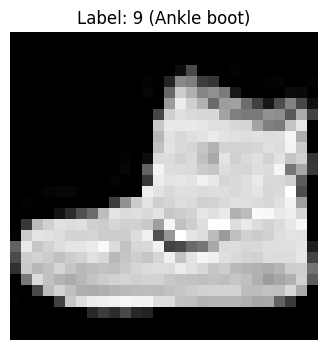

In [20]:
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]} ({class_names[y_train[0]]})")
plt.axis("off")
plt.show()

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [21]:
X_train_scaled = X_train / 255.0
X_test_scaled  = X_test / 255.0

In [22]:
X_train_scaled.min(), X_train_scaled.max()

(np.float64(0.0), np.float64(1.0))

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

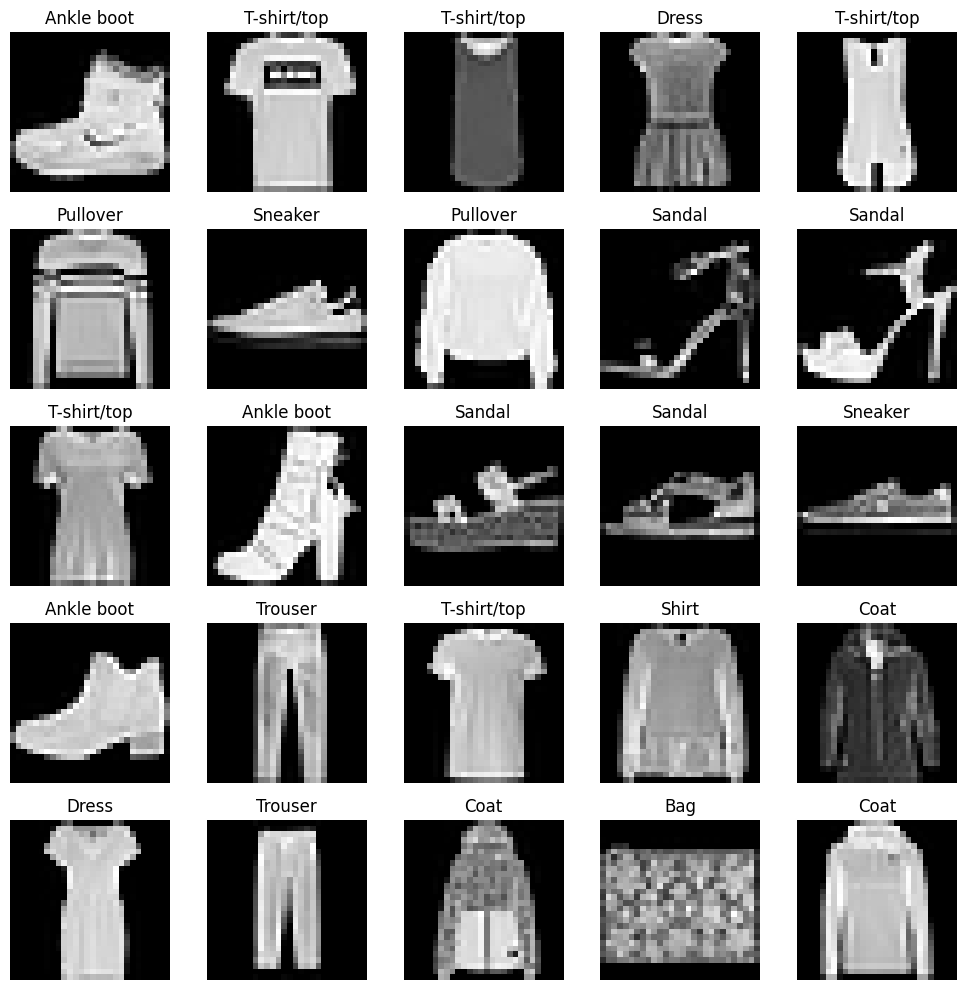

In [23]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_scaled[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [24]:
capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]

model = keras.models.Sequential(capas)

c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [25]:
model.compile(
    optimizer="adam", #ajusta atumáticamente el learning rate, más estable.
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [27]:
history = model.fit(
    X_train_scaled,
    y_train,
    batch_size = 32,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8247 - loss: 0.4897 - val_accuracy: 0.8493 - val_loss: 0.4159
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8655 - loss: 0.3660 - val_accuracy: 0.8732 - val_loss: 0.3518
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8780 - loss: 0.3309 - val_accuracy: 0.8733 - val_loss: 0.3623
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8865 - loss: 0.3046 - val_accuracy: 0.8757 - val_loss: 0.3367
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8921 - loss: 0.2885 - val_accuracy: 0.8767 - val_loss: 0.3271
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8984 - loss: 0.2725 - val_accuracy: 0.8827 - val_loss: 0.3248
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9035 - loss: 0.2588 - val_accuracy: 0.8852 - val_loss: 0.3359
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9057 - loss: 0.2482 - 

In [28]:
history_20 = model.fit(
    X_train_scaled,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9171 - loss: 0.2185 - val_accuracy: 0.8932 - val_loss: 0.3138
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9218 - loss: 0.2100 - val_accuracy: 0.8940 - val_loss: 0.3317
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9224 - loss: 0.2055 - val_accuracy: 0.8938 - val_loss: 0.3373
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9259 - loss: 0.1953 - val_accuracy: 0.8872 - val_loss: 0.3400
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9282 - loss: 0.1886 - val_accuracy: 0.8907 - val_loss: 0.3531
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9296 - loss: 0.1855 - val_accuracy: 0.8937 - val_loss: 0.3357
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9326 - loss: 0.1767 - val_accuracy: 0.8933 - val_loss: 0.3604
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9341 - loss: 0.1730 - 

Ha entrenado el modelo desde donde lo dejó.

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [31]:
results = model.evaluate(X_test_scaled, y_test)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8897 - loss: 0.4915


[0.49146226048469543, 0.8896999955177307]

In [32]:
print("Train accuracy:", history.history["accuracy"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])

Train accuracy: 0.9131481647491455
Validation accuracy: 0.8846666812896729


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [36]:
predictions = model.predict(X_test_scaled)
print(predictions.shape)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step
(10000, 10)


array([[8.8906196e-15, 3.1931353e-13, 5.6317002e-16, ..., 8.5367864e-09,
        1.9838819e-20, 9.9999917e-01],
       [1.0639599e-07, 6.9531329e-20, 9.9965012e-01, ..., 5.5498488e-12,
        8.7798790e-13, 2.9554423e-14],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [3.5755245e-13, 2.2443748e-28, 3.7521567e-22, ..., 1.4322607e-28,
        1.0000000e+00, 0.0000000e+00],
       [6.8547153e-33, 1.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        2.1061240e-32, 2.7586985e-38],
       [3.4345611e-14, 3.1404982e-25, 7.1538788e-16, ..., 1.6070981e-15,
        1.6610143e-13, 2.9055032e-19]], shape=(10000, 10), dtype=float32)

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [41]:
predicted_class = np.argmax(predictions[0])
print("Predicción:", class_names[predicted_class])
print("Real:", class_names[y_test[0]])

Predicción: Ankle boot
Real: Ankle boot


*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [49]:
np.max(predictions[0])

np.float32(0.99999917)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

In [50]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

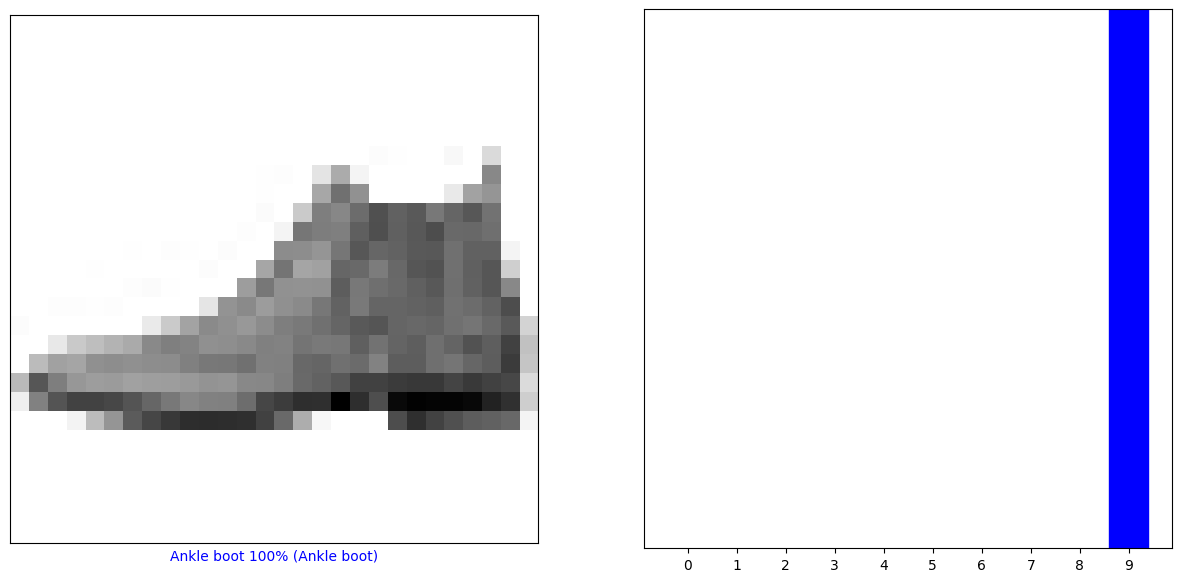

In [51]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], y_test)

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

Evalúa tu modelo con una matriz de confusión e interprétala.

In [52]:
y_pred_labels = np.argmax(predictions, axis=1)

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_labels)
cm

array([[889,   3,  12,   9,   4,   2,  76,   0,   5,   0],
       [  4, 981,   3,   8,   3,   0,   1,   0,   0,   0],
       [ 23,   0, 816,   8,  87,   0,  66,   0,   0,   0],
       [ 39,  10,   5, 869,  48,   0,  24,   0,   4,   1],
       [  0,   0,  85,  18, 829,   0,  64,   0,   4,   0],
       [  0,   0,   0,   0,   0, 971,   0,   7,   1,  21],
       [142,   1,  81,  30,  61,   0, 679,   0,   6,   0],
       [  0,   0,   0,   0,   0,  39,   0, 933,   0,  28],
       [  6,   0,   3,   1,   5,   6,   4,   5, 970,   0],
       [  0,   0,   0,   0,   0,   7,   1,  32,   0, 960]])

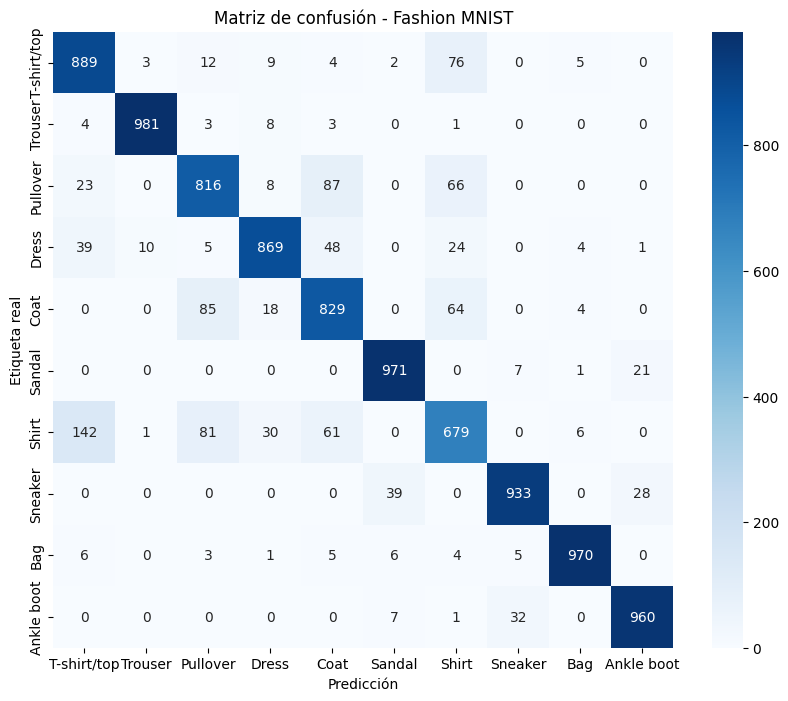

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Fashion MNIST")
plt.show()

La matriz de confusión muestra que el modelo presenta un buen rendimiento general, con la mayoría de las predicciones correctas situadas en la diagonal principal. Los errores se concentran principalmente entre clases visualmente similares como Shirt y T-shirt/top, o Pullover y Coat, lo cual es esperable dado el bajo nivel de resolución de las imágenes. Clases con formas más distintivas como Trouser, Bag o Sandal presentan tasas de acierto muy elevadas.

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [56]:
img = X_test_scaled[i]

In [57]:
img_batch = np.expand_dims(img, axis=0)

In [58]:
prediction = model.predict(img_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [59]:
predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("Predicción:", class_names[predicted_class])
print(f"Confianza: {confidence:.2f}%")
print("Etiqueta real:", class_names[y_test[i]])

Predicción: Ankle boot
Confianza: 100.00%
Etiqueta real: Ankle boot


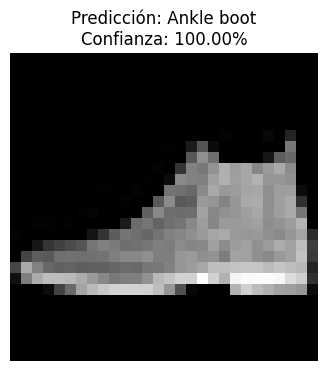

In [60]:
plt.figure(figsize=(4, 4))
plt.imshow(X_test[i], cmap="gray")
plt.title(
    f"Predicción: {class_names[predicted_class]}\n"
    f"Confianza: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicción: Bag
Confianza: 91.47%


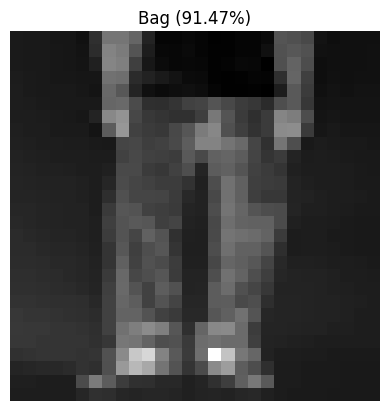

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

url = "https://img01.ztat.net/article/spp-media-p1/b01c2ba79abc4055bae0ee131486d3d8/1d03cd46e9ae489696dc591e0e992d8c.jpg?imwidth=300"

# 1. Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 2. Convertir a escala de grises y redimensionar a 28x28
img_gray = img.convert("L").resize((28, 28))

# 3. Pasar a array y normalizar (0–1)
x = np.array(img_gray).astype("float32") / 255.0

# 4. Invertir colores (muy recomendable para Fashion-MNIST)
x = 1.0 - x

# 5. Añadir dimensión batch
x_batch = np.expand_dims(x, axis=0)

# 6. Predicción
pred = model.predict(x_batch)
predicted_class = np.argmax(pred[0])
confidence = np.max(pred[0]) * 100

print("Predicción:", class_names[predicted_class])
print(f"Confianza: {confidence:.2f}%")

# 7. Mostrar imagen procesada
plt.imshow(x, cmap="gray")
plt.title(f"{class_names[predicted_class]} ({confidence:.2f}%)")
plt.axis("off")
plt.show()